# Get reference values for 100% covered surfaces


In [1]:
# Common imports
import sys
sys.path.append("../")

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.ndimage import distance_transform_edt
from sklearn.mixture import GaussianMixture

# from algorithm.processing.validation_data_processing import load_lpdr, load_GLWD, windsat_datacube
from algorithm.processing.validation_data_processing import select_data_variables, load_swf_validation_ds, \
    unravel_freqpol, read_config, atmospheric_corrections

xml_path = "validation_config.xml"

swf_config = read_config(xml_path)
data_paths = swf_config.get("paths")
print("LOCAL: ", swf_config.get("local"))

LOCAL:  True


In [7]:
ds = load_swf_validation_ds(
    **data_paths
)
ds = select_data_variables(ds)
# NOTE: additional processing and filtering is required
# we select only fore look
ds = ds.sel(look_direction=0)
# Select swath 0-ASC, 1-DES
# ds = ds.sel(swath_sector=0)

ds = atmospheric_corrections(ds)
ds

<xarray.Dataset> Size: 2GB
Dimensions:               (day_number: 11, polarization: 2, frequency_band: 2,
                           lat: 720, lon: 1440, swath_sector: 2)
Coordinates:
  * lat                   (lat) float32 3kB -89.88 -89.62 -89.38 ... 89.62 89.88
  * lon                   (lon) float32 6kB -179.9 -179.6 -179.4 ... 179.6 179.9
  * day_number            (day_number) int64 88B 1 2 3 4 5 6 7 8 9 10 196
Dimensions without coordinates: polarization, frequency_band, swath_sector
Data variables: (12/14)
    tbtoa                 (day_number, polarization, frequency_band, lat, lon, swath_sector) float32 365MB dask.array<chunksize=(1, 1, 1, 240, 480, 1), meta=np.ndarray>
    surtep_ERA5           (day_number, lat, lon, swath_sector) float32 91MB dask.array<chunksize=(1, 360, 720, 1), meta=np.ndarray>
    tran                  (day_number, polarization, frequency_band, lat, lon, swath_sector) float32 365MB dask.array<chunksize=(1, 1, 2, 360, 720, 1), meta=np.ndarray>
    tbdw                  (day_number, polarization, frequency_band, lat, lon, swath_sector) float32 365MB dask.array<chunksize=(1, 1, 2, 360, 720, 1), meta=np.ndarray>
    tbup                  (day_number, polarization, frequency_band, lat, lon, swath_sector) float32 365MB dask.array<chunksize=(1, 1, 2, 360, 720, 1), meta=np.ndarray>
    fwns                  (day_number, lat, lon) float32 46MB nan nan ... nan
    ...                    ...
    IGBP_landcover        (lat, lon) float32 4MB 12.0 12.0 12.0 ... 0.0 0.0 0.0
    all_classes_area_pct  (lat, lon) uint8 1MB 255 255 255 255 ... 255 255 255
    main_class            (lat, lon) uint8 1MB 255 255 255 255 ... 255 255 255
    main_class_50pct      (lat, lon) uint8 1MB 255 255 255 255 ... 255 255 255
    tbboa_1st_order       (day_number, polarization, frequency_band, lat, lon, swath_sector) float32 365MB dask.array<chunksize=(1, 1, 1, 240, 480, 1), meta=np.ndarray>
    tbboa_de_lannoy       (day_number, lat, lon, swath_sector, polarization, frequency_band) float32 365MB dask.array<chunksize=(1, 240, 480, 1, 1, 1), meta=np.ndarray>
Attributes: (12/72)
    Conventions:                            CF-1.7
    title:                                  RSS WindSat TOA Brightness Temper...
    version:                                V01.0
    summary:                                The dataset contains RSS WindSat ...
    references:                              [1] T. Meissner et al., Remote S...
    acknowledgement:                        Funded under NASA Grant 80NSSC21K...
    ...                                     ...
    Source_of_ancillary_IMERG_rain_rate:    Huffman, G. et al.,  2019. NASA G...
    Source_of_ancillary_CCMP_wind:          Mears, C. et al., 2023.Remote Sen...
    Source_of_ancillary_ERA5:               ECMWF Reanalysis v5 (ERA5). https...
    Source_of_RSS_WindSat_AS_ECV:           https://www.remss.com/missions/wi...
    Source_of_ancillary_HYCOM_SSS:          Hybrid Coordinate Ocean Model, Gl...
    Source_of_WindSat_L1C_TB:               T. Meissner et al., Remote Sensin...

In [8]:
# Unravel pol-freq fields into single bands. dataset should be 3D (day, lat, lon)
ds = unravel_freqpol(ds, dvars=[
    "tbtoa", "tbboa_1st_order", "tbboa_de_lannoy"
])

# Drop the multy dimentional dvars that we dont need anymore
ds = ds.drop_vars([
    "tbtoa", "tbup", "tbdw", "tran", "tbboa_1st_order", "tbboa_de_lannoy"
])

# NOTE: for the remote dataset we should filter windsat data only covering 2017 (day_number in [0,366])
ds = ds.sel(day_number=slice(0,366))
ds

<xarray.Dataset> Size: 1GB
Dimensions:               (day_number: 11, lat: 720, lon: 1440, swath_sector: 2)
Coordinates:
  * lat                   (lat) float32 3kB -89.88 -89.62 -89.38 ... 89.62 89.88
  * lon                   (lon) float32 6kB -179.9 -179.6 -179.4 ... 179.6 179.9
  * day_number            (day_number) int64 88B 1 2 3 4 5 6 7 8 9 10 196
Dimensions without coordinates: swath_sector
Data variables: (12/20)
    surtep_ERA5           (day_number, lat, lon, swath_sector) float32 91MB dask.array<chunksize=(1, 360, 720, 1), meta=np.ndarray>
    fwns                  (day_number, lat, lon) float32 46MB nan nan ... nan
    VOD                   (day_number, lat, lon) float32 46MB nan nan ... nan
    vsm                   (day_number, lat, lon) float32 46MB nan nan ... nan
    IGBP_landcover        (lat, lon) float32 4MB 12.0 12.0 12.0 ... 0.0 0.0 0.0
    all_classes_area_pct  (lat, lon) uint8 1MB 255 255 255 255 ... 255 255 255
    ...                    ...
    tbboa_1st_order37V    (day_number, lat, lon, swath_sector) float32 91MB dask.array<chunksize=(1, 240, 480, 1), meta=np.ndarray>
    tbboa_1st_order37H    (day_number, lat, lon, swath_sector) float32 91MB dask.array<chunksize=(1, 240, 480, 1), meta=np.ndarray>
    tbboa_de_lannoy19V    (day_number, lat, lon, swath_sector) float32 91MB dask.array<chunksize=(1, 240, 480, 1), meta=np.ndarray>
    tbboa_de_lannoy19H    (day_number, lat, lon, swath_sector) float32 91MB dask.array<chunksize=(1, 240, 480, 1), meta=np.ndarray>
    tbboa_de_lannoy37V    (day_number, lat, lon, swath_sector) float32 91MB dask.array<chunksize=(1, 240, 480, 1), meta=np.ndarray>
    tbboa_de_lannoy37H    (day_number, lat, lon, swath_sector) float32 91MB dask.array<chunksize=(1, 240, 480, 1), meta=np.ndarray>
Attributes: (12/72)
    Conventions:                            CF-1.7
    title:                                  RSS WindSat TOA Brightness Temper...
    version:                                V01.0
    summary:                                The dataset contains RSS WindSat ...
    references:                              [1] T. Meissner et al., Remote S...
    acknowledgement:                        Funded under NASA Grant 80NSSC21K...
    ...                                     ...
    Source_of_ancillary_IMERG_rain_rate:    Huffman, G. et al.,  2019. NASA G...
    Source_of_ancillary_CCMP_wind:          Mears, C. et al., 2023.Remote Sen...
    Source_of_ancillary_ERA5:               ECMWF Reanalysis v5 (ERA5). https...
    Source_of_RSS_WindSat_AS_ECV:           https://www.remss.com/missions/wi...
    Source_of_ancillary_HYCOM_SSS:          Hybrid Coordinate Ocean Model, Gl...
    Source_of_WindSat_L1C_TB:               T. Meissner et al., Remote Sensin...

In [15]:

# Get K- band emissivities with ERA5 skintemp
for freq in ["19", "37"]:
    for pol in ["H", "V"]:
        ds[f"emiss{freq}{pol}_ERA5"] = ds[f"tbtoa{freq}{pol}"] / ds["surtep_ERA5"]
        ds[f"emiss{freq}{pol}_1st_order"] = ds[f"tbboa_1st_order{freq}{pol}"] / ds["surtep_ERA5"]
        ds[f"emiss{freq}{pol}_de_lannoy"] = ds[f"tbboa_de_lannoy{freq}{pol}"] / ds["surtep_ERA5"]

emiss_bands = [
    "emiss19V_ERA5",
    "emiss19H_ERA5",
    "emiss37V_ERA5",
    "emiss37H_ERA5",
    "emiss19V_1st_order",
    "emiss19H_1st_order",
    "emiss37V_1st_order",
    "emiss37H_1st_order",
    "emiss19V_de_lannoy",
    "emiss19H_de_lannoy",
    "emiss37V_de_lannoy",
    "emiss37H_de_lannoy",
]
ds

<xarray.Dataset> Size: 2GB
Dimensions:               (day_number: 11, lat: 720, lon: 1440, swath_sector: 2)
Coordinates:
  * lat                   (lat) float32 3kB -89.88 -89.62 -89.38 ... 89.62 89.88
  * lon                   (lon) float32 6kB -179.9 -179.6 -179.4 ... 179.6 179.9
  * day_number            (day_number) int64 88B 1 2 3 4 5 6 7 8 9 10 196
Dimensions without coordinates: swath_sector
Data variables: (12/33)
    surtep_ERA5           (day_number, lat, lon, swath_sector) float32 91MB dask.array<chunksize=(1, 360, 720, 1), meta=np.ndarray>
    fwns                  (day_number, lat, lon) float32 46MB nan nan ... nan
    VOD                   (day_number, lat, lon) float32 46MB nan nan ... nan
    vsm                   (day_number, lat, lon) float32 46MB nan nan ... nan
    IGBP_landcover        (lat, lon) float32 4MB 12.0 12.0 12.0 ... 0.0 0.0 0.0
    all_classes_area_pct  (lat, lon) uint8 1MB 255 255 255 255 ... 255 255 255
    ...                    ...
    emiss37H_1st_order    (day_number, lat, lon, swath_sector) float32 91MB dask.array<chunksize=(1, 240, 480, 1), meta=np.ndarray>
    emiss37H_de_lannoy    (day_number, lat, lon, swath_sector) float32 91MB dask.array<chunksize=(1, 240, 480, 1), meta=np.ndarray>
    emiss37V_ERA5         (day_number, lat, lon, swath_sector) float32 91MB dask.array<chunksize=(1, 240, 480, 1), meta=np.ndarray>
    emiss37V_1st_order    (day_number, lat, lon, swath_sector) float32 91MB dask.array<chunksize=(1, 240, 480, 1), meta=np.ndarray>
    emiss37V_de_lannoy    (day_number, lat, lon, swath_sector) float32 91MB dask.array<chunksize=(1, 240, 480, 1), meta=np.ndarray>
    lake_mask             (lat, lon) float32 4MB nan nan nan nan ... nan nan nan
Attributes: (12/72)
    Conventions:                            CF-1.7
    title:                                  RSS WindSat TOA Brightness Temper...
    version:                                V01.0
    summary:                                The dataset contains RSS WindSat ...
    references:                              [1] T. Meissner et al., Remote S...
    acknowledgement:                        Funded under NASA Grant 80NSSC21K...
    ...                                     ...
    Source_of_ancillary_IMERG_rain_rate:    Huffman, G. et al.,  2019. NASA G...
    Source_of_ancillary_CCMP_wind:          Mears, C. et al., 2023.Remote Sen...
    Source_of_ancillary_ERA5:               ECMWF Reanalysis v5 (ERA5). https...
    Source_of_RSS_WindSat_AS_ECV:           https://www.remss.com/missions/wi...
    Source_of_ancillary_HYCOM_SSS:          Hybrid Coordinate Ocean Model, Gl...
    Source_of_WindSat_L1C_TB:               T. Meissner et al., Remote Sensin...

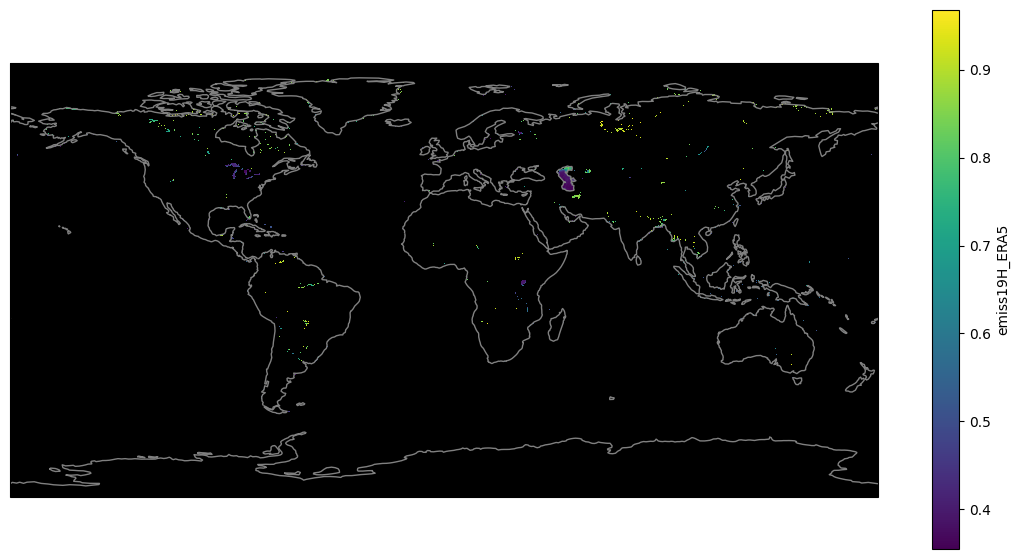

In [16]:
# Experiment 1: select only 100% GLWD waterbody area
selection_ds = ds.where(ds.all_classes_area_pct == 100)

# Visualize space selection
fig, ax = plt.subplots(1, 1, figsize=(14, 7), subplot_kw={"projection": ccrs.PlateCarree()})
selection_ds.emiss19H_ERA5.mean(dim=["day_number", "swath_sector"]).plot(ax=ax)
ax.coastlines("110m", color="gray")
ax.set_facecolor("black")

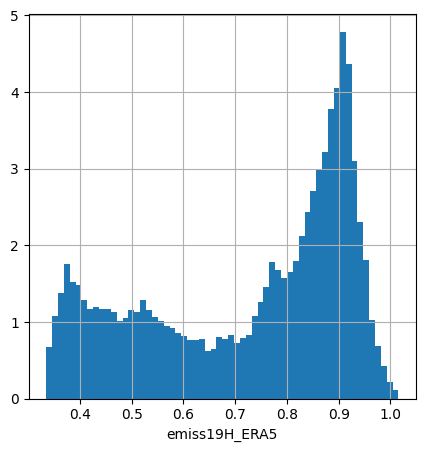

In [17]:
# NOTE: only for local testing
if swf_config.get("local"):
    fig, ax = plt.subplots(1,1,figsize=(5,5))
    selection_ds.emiss19H_ERA5.plot.hist(bins=60, density=True)
    ax.grid()

## We still get the land comtamination
Let's try to filter only the pixels that are completely inside a lake (big lakes) while removing the shore.

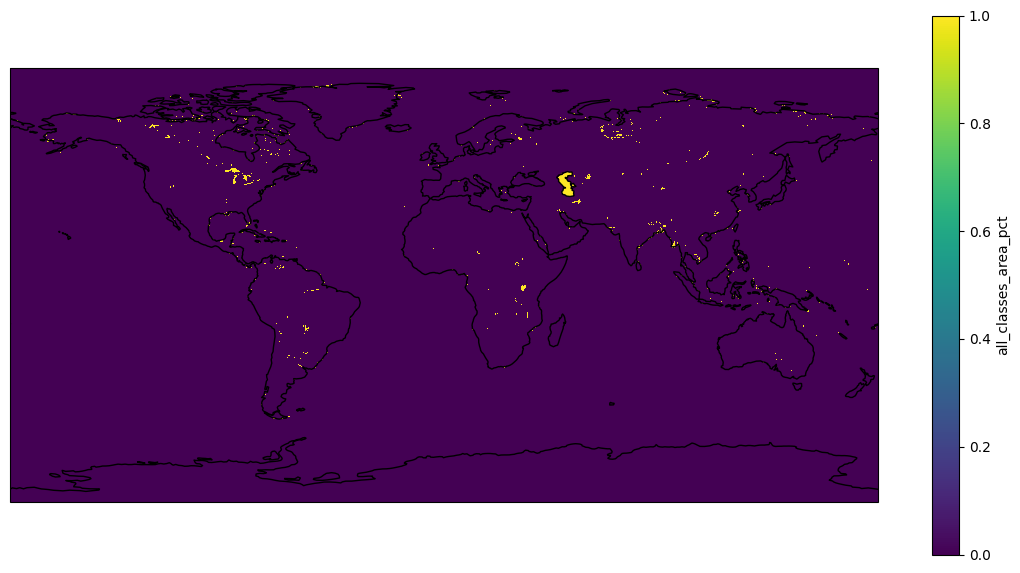

In [18]:
# Remove pixels from the edge: create a 0 - 1 mask the use scipy.ndimage.distance_transform_edt
base_mask = ds.all_classes_area_pct.copy()
lake_mask = base_mask.where(ds.all_classes_area_pct, other=0)

# change 100% to 1 and other to 0
lake_mask = lake_mask.where(lake_mask==100, other=0)
lake_mask = lake_mask // 100

fig, ax = plt.subplots(1, 1, figsize=(14, 7), subplot_kw={"projection": ccrs.PlateCarree()})

lake_mask.plot(ax=ax)
ax.coastlines("110m")



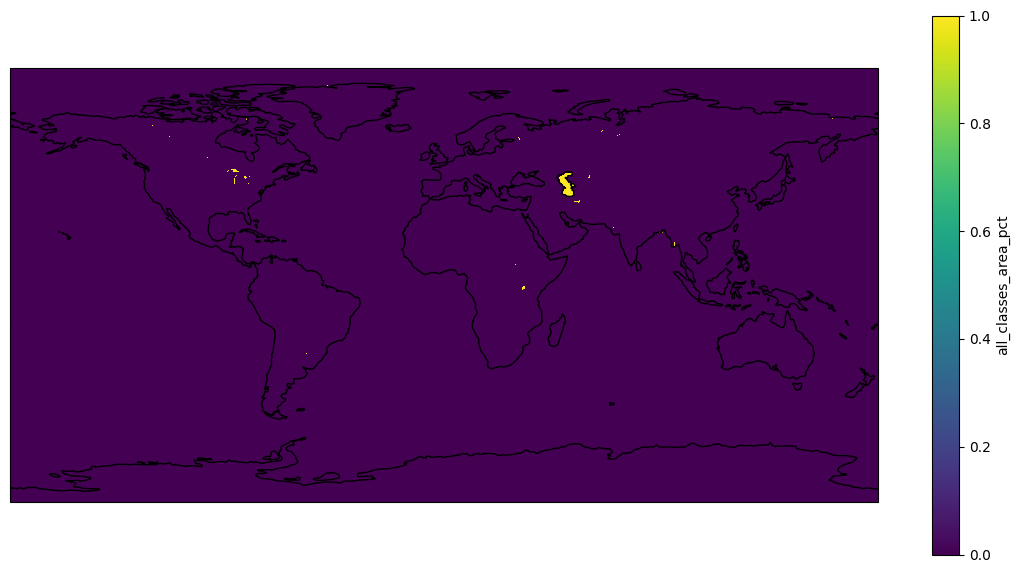

In [19]:
# calculate edh and remove all pixels with distance 1
shore_distance = distance_transform_edt(lake_mask.values)

# NOTE: only for visualization purposes:
to_plot = lake_mask.where(shore_distance > 1, other=0)
fig, ax = plt.subplots(1, 1, figsize=(14, 7), subplot_kw={"projection": ccrs.PlateCarree()})

to_plot.plot(ax=ax)
ax.coastlines("110m")

# We now use this new mask to get emissivty values
lake_mask = lake_mask.where(shore_distance > 1)
ds["lake_mask"] = (("lat", "lon"), lake_mask.values)
selection_ds = ds.where(ds.lake_mask == 1)


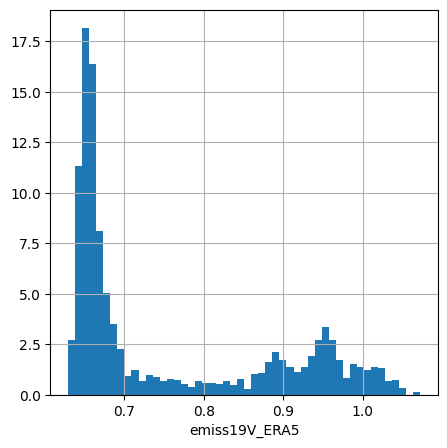

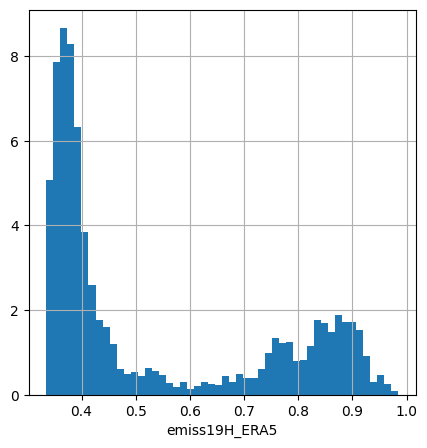

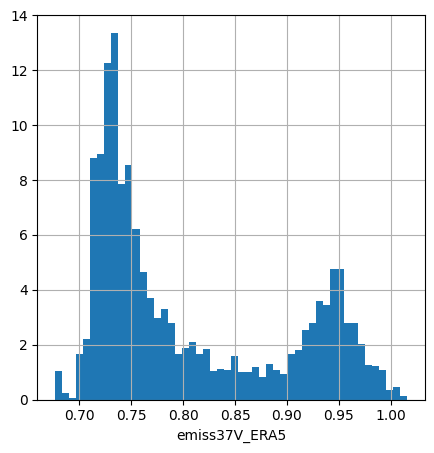

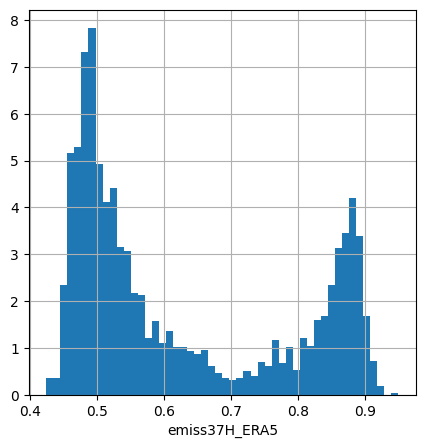

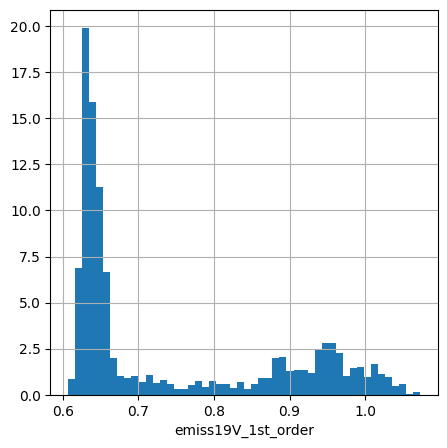

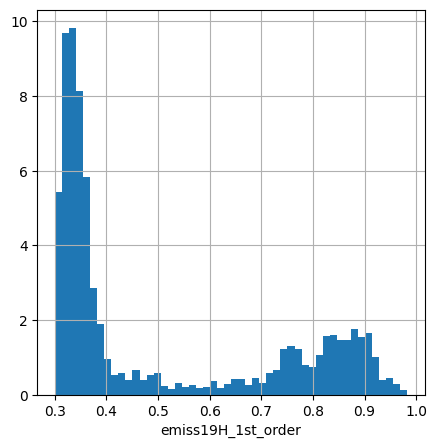

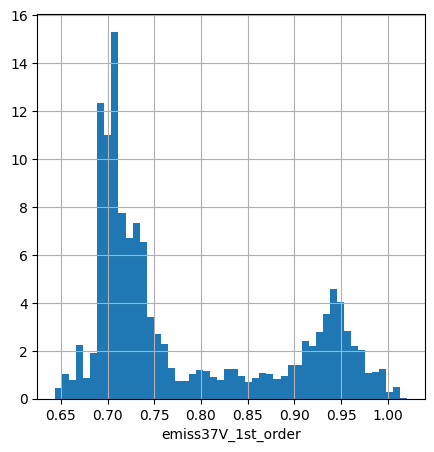

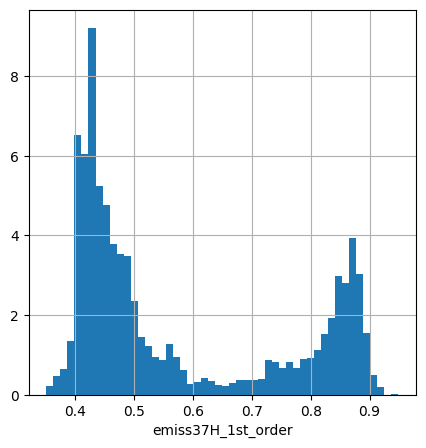

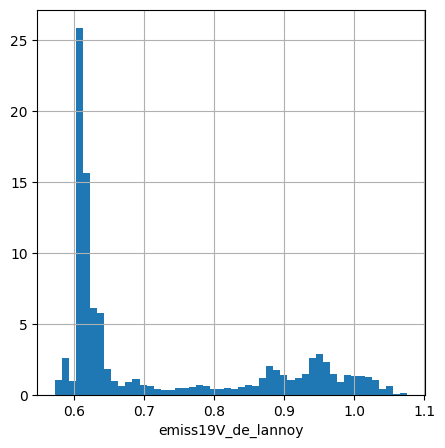

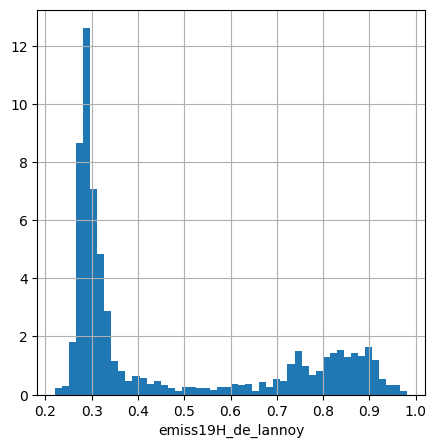

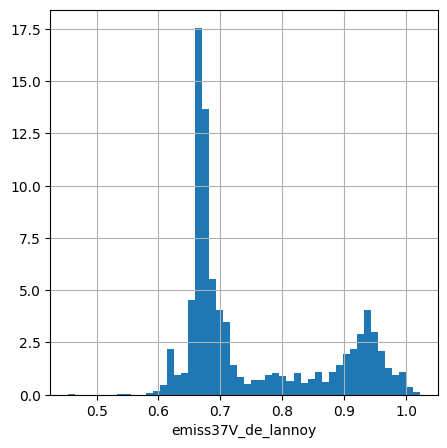

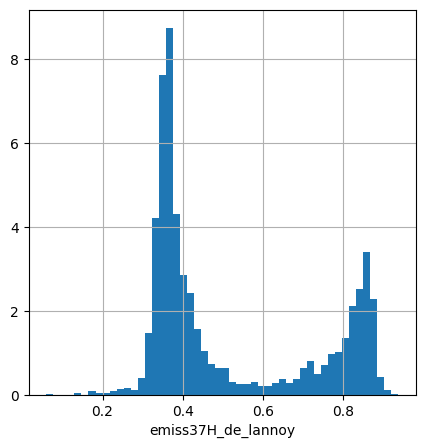

In [20]:
# # Last run, one plot for each band:
# # Let's extract a numerical values, one reference emissivty and its STD.

# NOTE: only for local testing
if swf_config.get("local"):
    for dvar in emiss_bands:
        # NOTE: Map is basically the same with a different scale

        # Histogram
        _, ax = plt.subplots(1, 1, figsize=(5, 5))
        selection_ds[dvar].plot.hist(bins=50, density=True)
        ax.grid()
        ax.set_xlabel(dvar)

## Lets fit a gaussian mixture with 2 components: Lland emiss and water

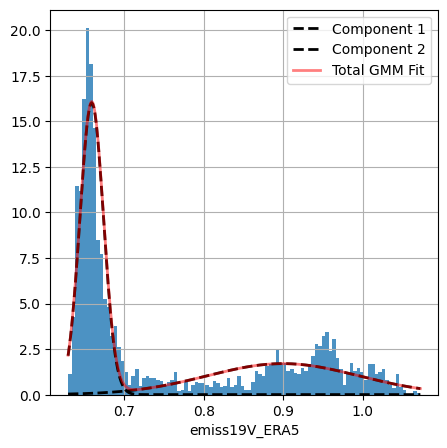

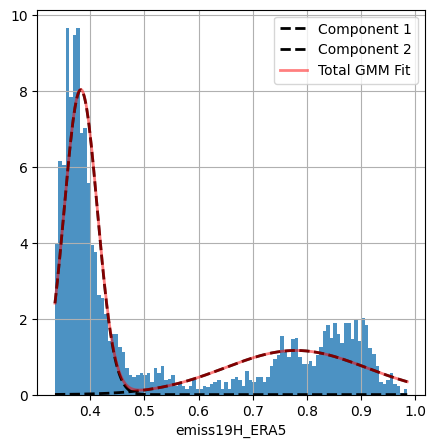

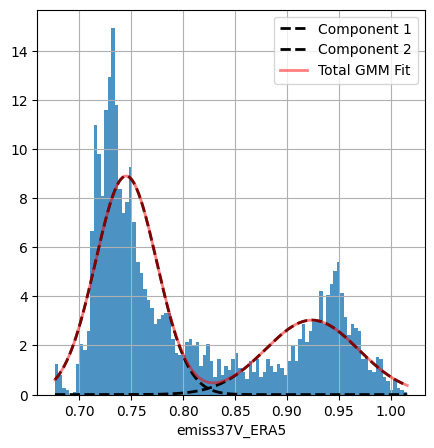

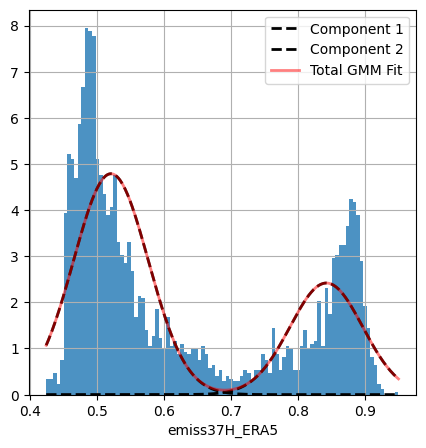

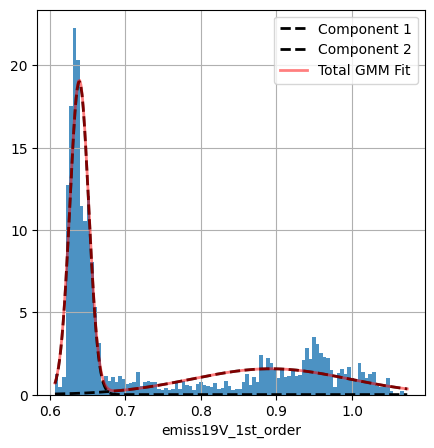

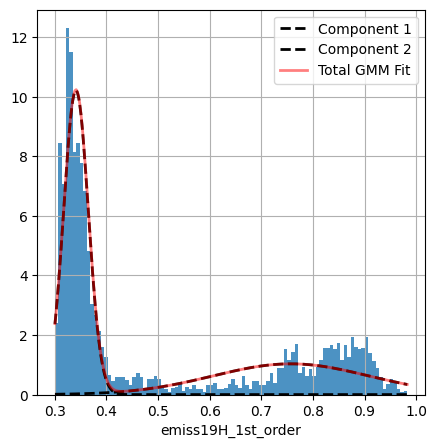

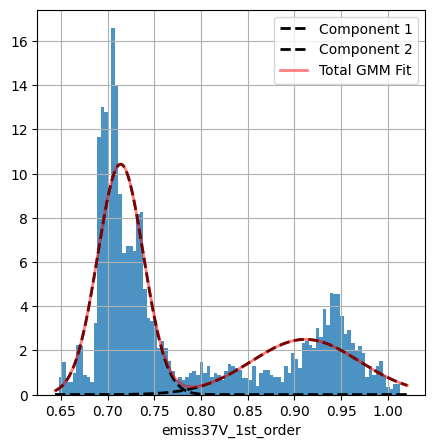

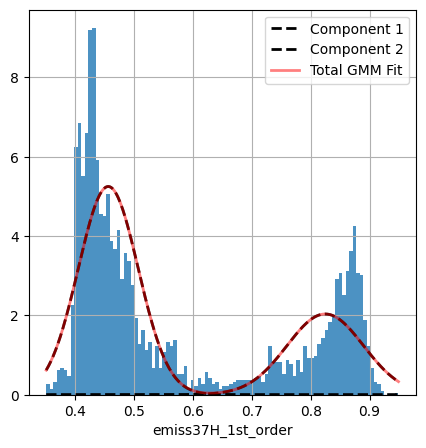

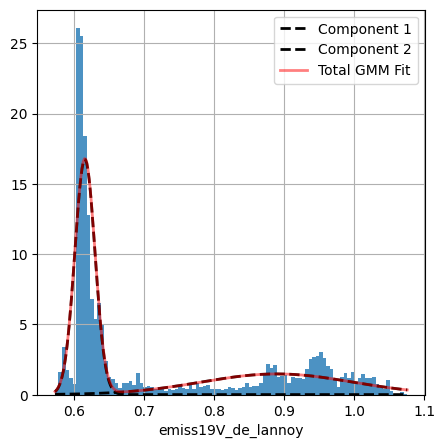

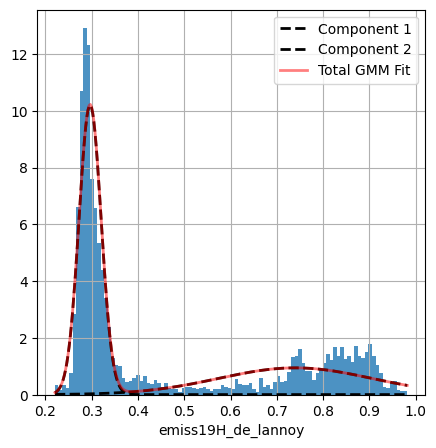

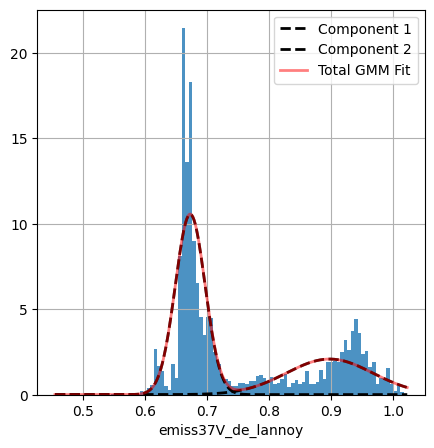

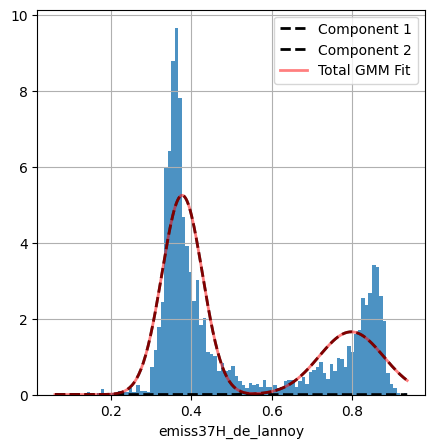

In [21]:

distributions = []
main_components = []
for dvar in emiss_bands:
    # Fit GM
    data = selection_ds[dvar].values
    data = data[~np.isnan(data)]
    gm = GaussianMixture(n_components=2)
    gm.fit(data.reshape(-1,1))

    means = gm.means_.flatten()
    stds = np.sqrt(gm.covariances_).flatten()
    weights = gm.weights_
    distributions.append((means, stds))

    # Get the main component index
    main_component = np.argmax(gm.weights_)
    main_components.append((means[main_component], stds[main_component]))

    # Histogram
    _, ax = plt.subplots(1, 1, figsize=(5, 5))
    n, bins, patches = selection_ds[dvar].plot.hist(bins=100, density=True, alpha=0.8)

    # Generate x values for smooth curve
    x = np.linspace(bins.min(), bins.max(), 300)

    # Compute and plot each Gaussian component
    y_total = np.zeros_like(x)
    for mean, std, weight in zip(means, stds, weights):
        y = weight * norm.pdf(x, mean, std)  # Weighted Gaussian
        y_total += y  # Sum components
        ax.plot(x, y, "k--", linewidth=2)  # Individual component

    # Plot total mixture distribution
    ax.plot(x, y_total, "r-", linewidth=2, label="GMM Fit", alpha=0.5)

    ax.grid()
    ax.set_xlabel(dvar)
    ax.legend(["Component 1", "Component 2", "Total GMM Fit"])
    plt.show()

In [23]:
# Sumary
df_main_components = pd.DataFrame(main_components, columns=["Mean", "Std"], index=emiss_bands)
df_main_components


,Mean,Std
emiss19V_ERA5,0.659147,0.014791
emiss19H_ERA5,0.382413,0.030657
emiss37V_ERA5,0.745109,0.029544
emiss37H_ERA5,0.520415,0.055842
emiss19V_1st_order,0.639093,0.012419
emiss19H_1st_order,0.341157,0.023788
emiss37V_1st_order,0.713935,0.024469
emiss37H_1st_order,0.456478,0.050863
emiss19V_de_lannoy,0.615568,0.014351
emiss19H_de_lannoy,0.296539,0.023851


In [24]:
# Save to csv just in case it crashes
df_main_components.to_csv("open_water_emiss.csv")

# This method get a reference emissivty that is shifted:  
Let's repeat the fit arround the main component

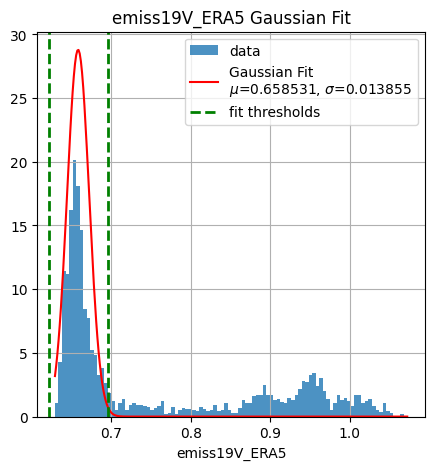

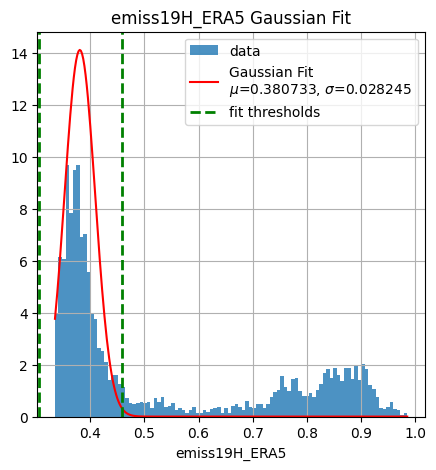

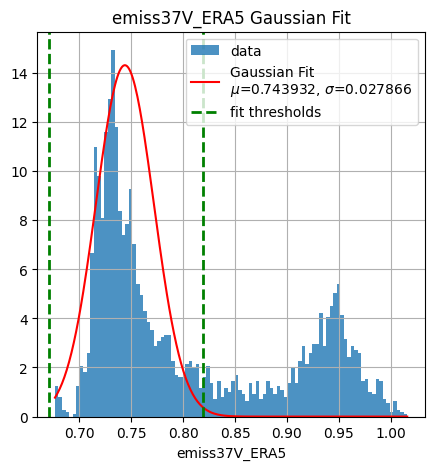

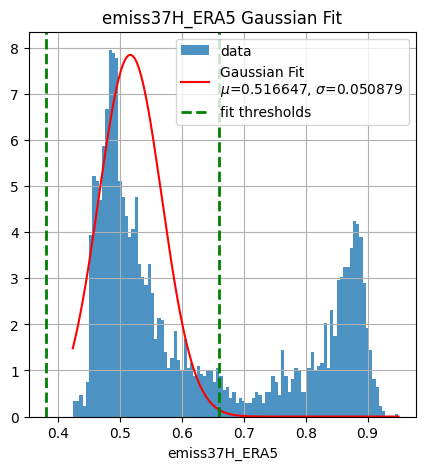

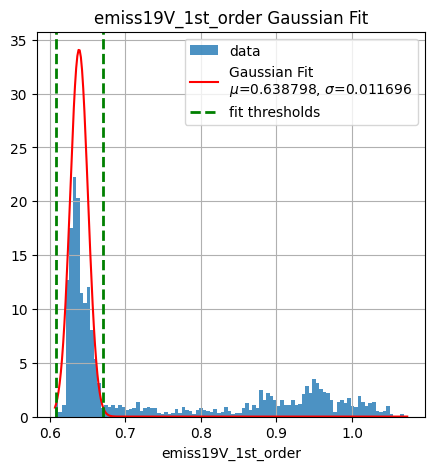

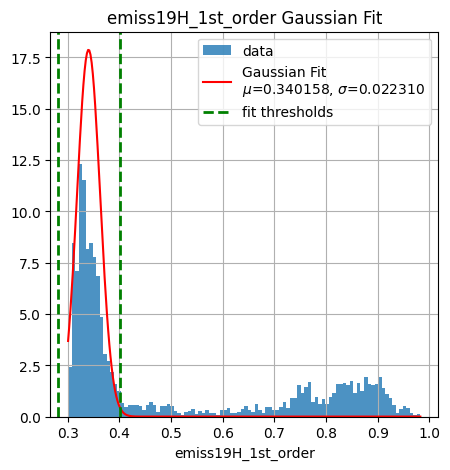

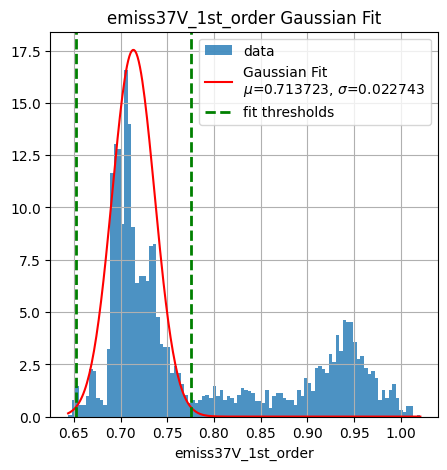

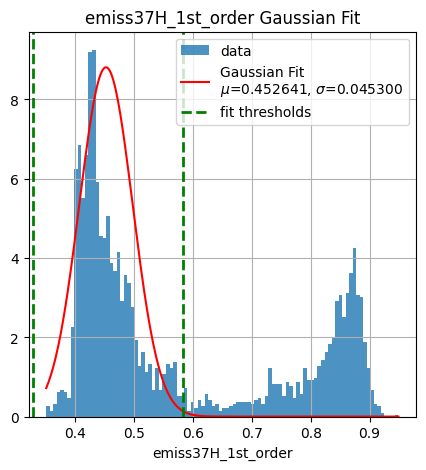

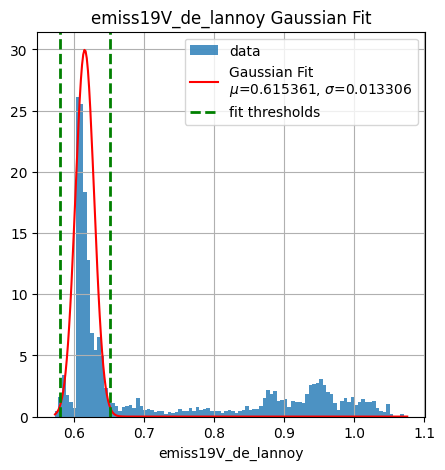

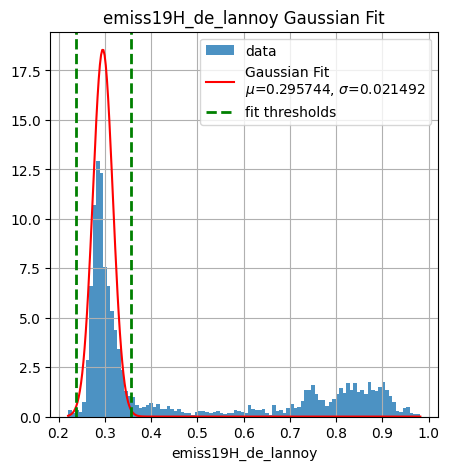

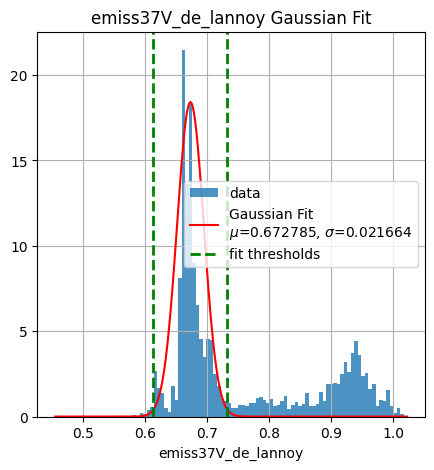

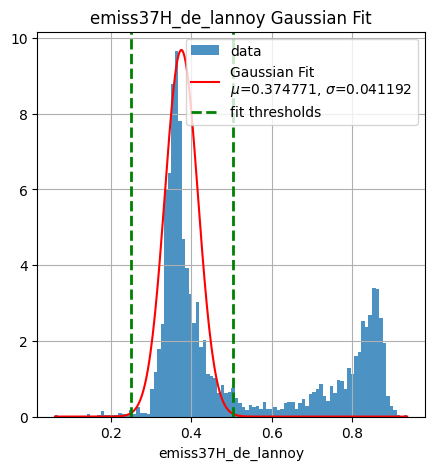

In [22]:
from scipy.stats import norm

n_std = 2.5
for i, dvar in enumerate(emiss_bands):
    # Filter values in between n_std of the main component
    mc_mu, mc_std = main_components[i]
    lower_threshold = mc_mu - n_std * mc_std
    upper_threshold = mc_mu + n_std * mc_std

    emis_ds = selection_ds.where(
        selection_ds[dvar] > lower_threshold
    ).where(
        selection_ds[dvar] < upper_threshold
    )
    data = emis_ds[dvar].values
    data = data[~np.isnan(data)]

    # Fit a single Gaussian distr:
    mu, sigma = norm.fit(data)
    
    # Histogram
    _, ax = plt.subplots(1, 1, figsize=(5, 5))
    n, bins, patches = selection_ds[dvar].plot.hist(
        bins=100, density=True, alpha=0.8, label= "data",
    )

    # Generate x values for smooth curve
    x = np.linspace(bins.min(), bins.max(), 300)
    pdf = norm.pdf(x, mu, sigma)

    # Overlay the fitted Gaussian curve
    ax.plot(x, pdf, "r-", label=f'Gaussian Fit\n$\mu$={mu:.6f}, $\sigma$={sigma:.6f}')
    ax.grid()
    ax.set_xlabel(dvar)

    ax.set_title(f"{dvar} Gaussian Fit")
    # Add the thresholds for the fit:
    ax.axvline(lower_threshold, color='g', linestyle='--', linewidth=2, label = "fit thresholds")
    ax.axvline(upper_threshold, color='g', linestyle='--', linewidth=2)

    ax.legend()

